We are creating a Domain-Specific Q&A Chatbot using TF-IDF + Cosine Similarity that answers user questions based on a specific domain dataset or knowledge.<br>
This is a retrieval-based chatbot (like FAQ bots used in websites, universities, banks, etc.)


In [22]:
# ============================================================
# CELL 1: Importing Libraries and Setting Up the Environment
# ============================================================

# Import built-in Python libraries
import os
import re
import pickle
import warnings

# Import data handling libraries
import numpy as np
import pandas as pd

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Ignore warnings
warnings.filterwarnings("ignore")

# Create required folders
os.makedirs("models", exist_ok=True)
os.makedirs("figures", exist_ok=True)

# Confirmation message
print("Project setup completed successfully!")

Project setup completed successfully!


First 5 rows of dataset:
                                            question  \
0  What is the role of Siamese networks in domain...   
1          What is a recurrent neural network (RNN)?   
2  What are Eigen values and Eigen vectors in the...   
3                          What are Deep Q-Networks?   
4     What properties of words can Word2Vec extract?   

                                              answer     domain  
0  Siamese networks can be used to align the repr...  education  
1  An RNN handles sequence data, capturing tempor...  education  
2  Eigen values represent the variance captured b...  education  
3  Deep Q-networks are neural networks that appro...  education  
4  Word2Vec can extract and provide the most simi...  education  

Dataset Shape: (1985, 3)

Columns in Dataset:
['question', 'answer', 'domain']

Domain Distribution:
domain
education    1985
Name: count, dtype: int64


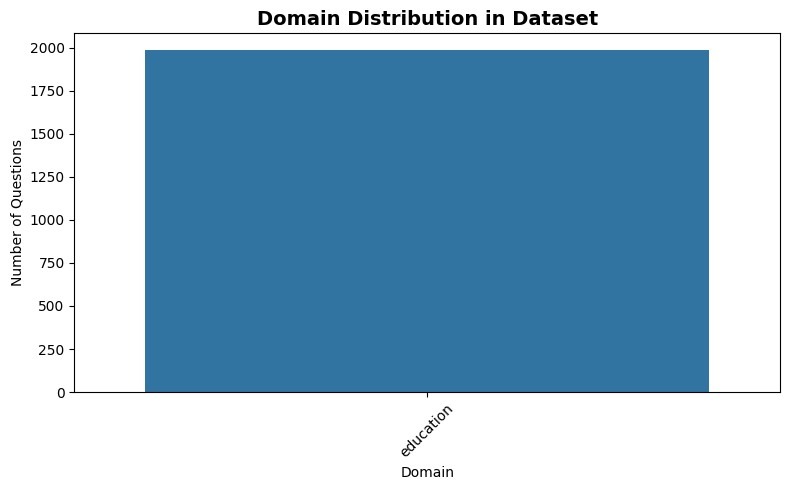

In [23]:
# ============================================================
# CELL 2: Data Loading and Initial Exploration
# ============================================================

def load_dataset(file_path):
    """
    Load and perform initial exploration of the Q&A dataset.
    """

    # Load dataset
    df = pd.read_csv(file_path)

    # Display first 5 rows
    print("First 5 rows of dataset:")
    print(df.head())

    # Display dataset shape
    print("\nDataset Shape:", df.shape)

    # Display column names
    print("\nColumns in Dataset:")
    print(df.columns.tolist())

    # Display domain distribution
    print("\nDomain Distribution:")
    print(df["domain"].value_counts())

    # Visualize domain distribution
    plt.figure(figsize=(8, 5))
    sns.countplot(x="domain", data=df)
    plt.title("Domain Distribution in Dataset", fontsize=14, fontweight="bold")
    plt.xlabel("Domain")
    plt.ylabel("Number of Questions")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig("figures/domain_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()

    return df


# Load dataset
df = load_dataset("qa_dataset.csv")

In [24]:
# ============================================================
# CELL 3: Data Cleaning, Missing Values, and Duplicates
# ============================================================

def clean_dataset(df):
    """
    Clean the Q&A dataset by:
    1. Checking required columns
    2. Removing missing values
    3. Removing duplicate rows
    4. Resetting index
    """

    # Required columns
    required_columns = ["domain", "question", "answer"]

    # Check if all required columns exist
    for column in required_columns:
        if column not in df.columns:
            raise ValueError(f"Missing required column: {column}")

    # Keep only required columns
    df = df[required_columns]

    # Check missing values
    print("Missing Values Before Cleaning:")
    print(df.isnull().sum())

    # Remove missing values
    df.dropna(inplace=True)

    # Check missing values again
    print("\nMissing Values After Cleaning:")
    print(df.isnull().sum())

    # Check duplicate rows
    print(f"\nDuplicate rows found: {df.duplicated().sum()}")

    # Remove duplicate rows
    df.drop_duplicates(inplace=True)

    # Check duplicates again
    print(f"Duplicates after removal: {df.duplicated().sum()}")

    # Reset index
    df = df.reset_index(drop=True)

    # Display first rows after cleaning
    print("\nFirst 5 rows after cleaning:")
    print(df.head())

    return df


# Clean dataset
df = clean_dataset(df)

Missing Values Before Cleaning:
domain      0
question    0
answer      0
dtype: int64

Missing Values After Cleaning:
domain      0
question    0
answer      0
dtype: int64

Duplicate rows found: 0
Duplicates after removal: 0

First 5 rows after cleaning:
      domain                                           question  \
0  education  What is the role of Siamese networks in domain...   
1  education          What is a recurrent neural network (RNN)?   
2  education  What are Eigen values and Eigen vectors in the...   
3  education                          What are Deep Q-Networks?   
4  education     What properties of words can Word2Vec extract?   

                                              answer  
0  Siamese networks can be used to align the repr...  
1  An RNN handles sequence data, capturing tempor...  
2  Eigen values represent the variance captured b...  
3  Deep Q-networks are neural networks that appro...  
4  Word2Vec can extract and provide the most simi...  


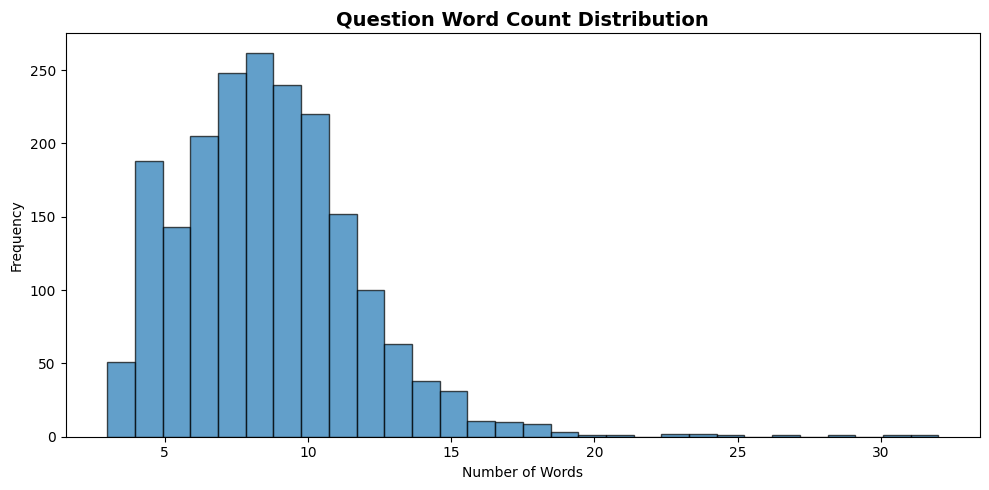

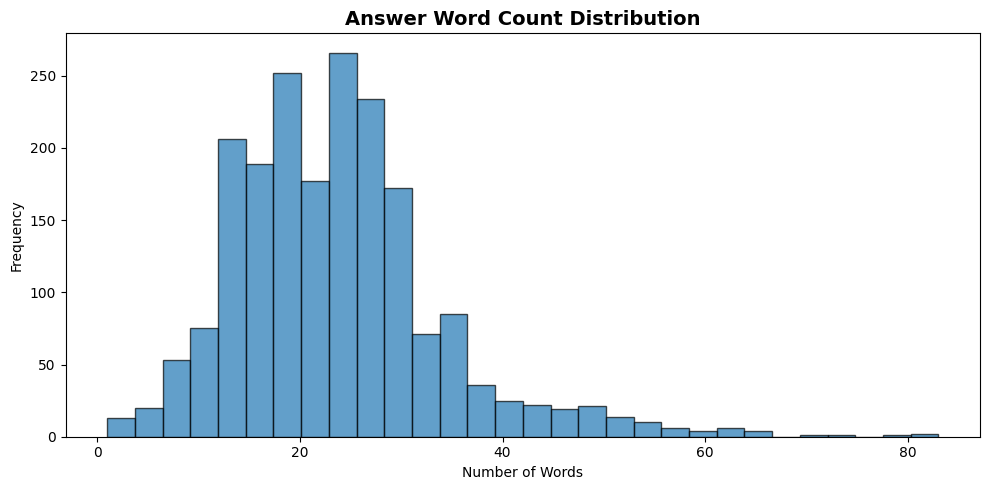

In [25]:
# ============================================================
# CELL 4: Dataset Visualization
# ============================================================

def visualize_dataset(df):
    """
    Create basic visualizations for understanding the Q&A dataset.
    """

    # Create question word length column
    df["question_word_count"] = df["question"].apply(lambda x: len(str(x).split()))

    # Create answer word length column
    df["answer_word_count"] = df["answer"].apply(lambda x: len(str(x).split()))

    # Visualize question length distribution
    plt.figure(figsize=(10, 5))
    plt.hist(df["question_word_count"], bins=30, edgecolor="black", alpha=0.7)
    plt.title("Question Word Count Distribution", fontsize=14, fontweight="bold")
    plt.xlabel("Number of Words")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig("figures/question_length_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()

    # Visualize answer length distribution
    plt.figure(figsize=(10, 5))
    plt.hist(df["answer_word_count"], bins=30, edgecolor="black", alpha=0.7)
    plt.title("Answer Word Count Distribution", fontsize=14, fontweight="bold")
    plt.xlabel("Number of Words")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig("figures/answer_length_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()

    return df


# Visualize dataset
df = visualize_dataset(df)

In [26]:
# ============================================================
# CELL 5: Text Preprocessing
# ============================================================

def preprocess_text(text):
    """
    Clean text before applying TF-IDF.
    """

    # Convert text to string and lowercase
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove numbers
    text = re.sub(r"\d+", " ", text)

    # Remove special characters and punctuation
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


# Apply preprocessing on questions
print("Applying text preprocessing...")

df["question"] = df["question"].apply(preprocess_text)

# Remove empty questions after preprocessing
df = df[df["question"] != ""]

# Reset index
df = df.reset_index(drop=True)

# Confirmation message
print("Text preprocessing completed!")
print("Number of rows after preprocessing:", len(df))

# Display cleaned data
df[["domain", "question", "answer"]].head()

Applying text preprocessing...
Text preprocessing completed!
Number of rows after preprocessing: 1985


,domain,question,answer
0,education,what is the role of siamese networks in domain...,Siamese networks can be used to align the repr...
1,education,what is a recurrent neural network rnn,"An RNN handles sequence data, capturing tempor..."
2,education,what are eigen values and eigen vectors in the...,Eigen values represent the variance captured b...
3,education,what are deep q networks,Deep Q-networks are neural networks that appro...
4,education,what properties of words can word vec extract,Word2Vec can extract and provide the most simi...


In [27]:
# ============================================================
# CELL 6: TF-IDF Feature Extraction
# ============================================================

def create_tfidf_features(df):
    """
    Convert cleaned questions into numerical TF-IDF vectors.
    """

    # Create TF-IDF vectorizer
    tfidf_vectorizer = TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 3),
        stop_words="english"
    )

    # Fit and transform clean questions
    question_vectors = tfidf_vectorizer.fit_transform(df["question"])

    # Print TF-IDF shape
    print("TF-IDF Matrix Shape:", question_vectors.shape)

    return tfidf_vectorizer, question_vectors


# Create TF-IDF features
tfidf_vectorizer, question_vectors = create_tfidf_features(df)

TF-IDF Matrix Shape: (1985, 9930)


In [28]:
# ============================================================
# CELL 7: Top Matched Questions Using Cosine Similarity
# ============================================================

def get_top_matches(user_query, df, tfidf_vectorizer, question_vectors, domain="education", top_k=3):
    """
    Find top-k most similar questions from the dataset.
    """

    # Preprocess user query
    clean_query = preprocess_text(user_query)

    # Filter dataset by selected domain
    filtered_df = df[df["domain"] == domain].reset_index(drop=True)

    # If selected domain has no data
    if filtered_df.empty:
        return []

    # Re-transform filtered questions
    filtered_vectors = tfidf_vectorizer.transform(filtered_df["question"])

    # Convert user query into TF-IDF vector
    query_vector = tfidf_vectorizer.transform([clean_query])

    # Calculate cosine similarity
    similarity_scores = cosine_similarity(query_vector, filtered_vectors).flatten()

    # Get top-k indices
    top_indices = similarity_scores.argsort()[-top_k:][::-1]

    # Store top results
    top_matches = []

    for index in top_indices:
        top_matches.append({
            "domain": filtered_df.iloc[index]["domain"],
            "matched_question": filtered_df.iloc[index]["question"],
            "answer": filtered_df.iloc[index]["answer"],
            "similarity_score": round(float(similarity_scores[index]), 3)
        })

    return top_matches

In [29]:
# ============================================================
# CELL 8: Final Chatbot Response Function
# ============================================================

def chatbot_response(
    user_query,
    df,
    tfidf_vectorizer,
    question_vectors,
    domain="education",
    threshold=0.30,
    top_k=3
):
    """
    Generate chatbot response using TF-IDF and cosine similarity.
    """

    # Check empty input
    if user_query is None or user_query.strip() == "":
        return {
            "answer": "Please enter a valid question.",
            "matched_question": None,
            "similarity_score": 0.0,
            "top_matches": []
        }

    # Get top matched questions
    top_matches = get_top_matches(
        user_query=user_query,
        df=df,
        tfidf_vectorizer=tfidf_vectorizer,
        question_vectors=question_vectors,
        domain=domain,
        top_k=top_k
    )

    # Check if no matches found
    if len(top_matches) == 0:
        return {
            "answer": "No data found for the selected domain.",
            "matched_question": None,
            "similarity_score": 0.0,
            "top_matches": []
        }

    # Select best match
    best_match = top_matches[0]

    # Apply similarity threshold
    if best_match["similarity_score"] < threshold:
        return {
            "answer": "Sorry, I don't understand your question. Please ask something related to AI, Machine Learning, Deep Learning, NLP, or Data Science.",
            "matched_question": None,
            "similarity_score": best_match["similarity_score"],
            "top_matches": top_matches
        }

    # Return best answer
    return {
        "answer": best_match["answer"],
        "matched_question": best_match["matched_question"],
        "similarity_score": best_match["similarity_score"],
        "top_matches": top_matches
    }

In [30]:
# ============================================================
# CELL 9: Test Q&A Chatbot with Sample Questions
# ============================================================

# Sample test questions
test_questions = [
    "What is machine learning?",
    "Explain backpropagation",
    "What is transformer model?",
    "What is cosine similarity?",
    "Tell me about football"
]

# Test chatbot
for question in test_questions:

    response = chatbot_response(
        user_query=question,
        df=df,
        tfidf_vectorizer=tfidf_vectorizer,
        question_vectors=question_vectors,
        domain="education",
        threshold=0.30,
        top_k=3
    )

    # Print result
    print("User Question:", question)
    print("Matched Question:", response["matched_question"])
    print("Similarity Score:", response["similarity_score"])
    print("Bot Answer:", response["answer"])

    print("\nTop Matches:")
    for match in response["top_matches"]:
        print("-", match["matched_question"], "| Score:", match["similarity_score"])

    print("-" * 80)

User Question: What is machine learning?
Matched Question: what is machine learning
Similarity Score: 1.0
Bot Answer: Machine Learning is a branch of Artificial Intelligence that involves the design and development of algorithms that enable computers to capture and model behaviors based on empirical data

Top Matches:
- what is machine learning | Score: 1.0
- what is machine learning | Score: 1.0
- what is overfitting in machine learning | Score: 0.506
--------------------------------------------------------------------------------
User Question: Explain backpropagation
Matched Question: what is backpropagation
Similarity Score: 0.787
Bot Answer: The algorithm used to compute gradients and update weights in a neural network during training.

Top Matches:
- what is backpropagation | Score: 0.787
- what is backpropagation in deep learning | Score: 0.33
- explain the concept of backpropagation in the context of neural networks | Score: 0.315
-----------------------------------------------

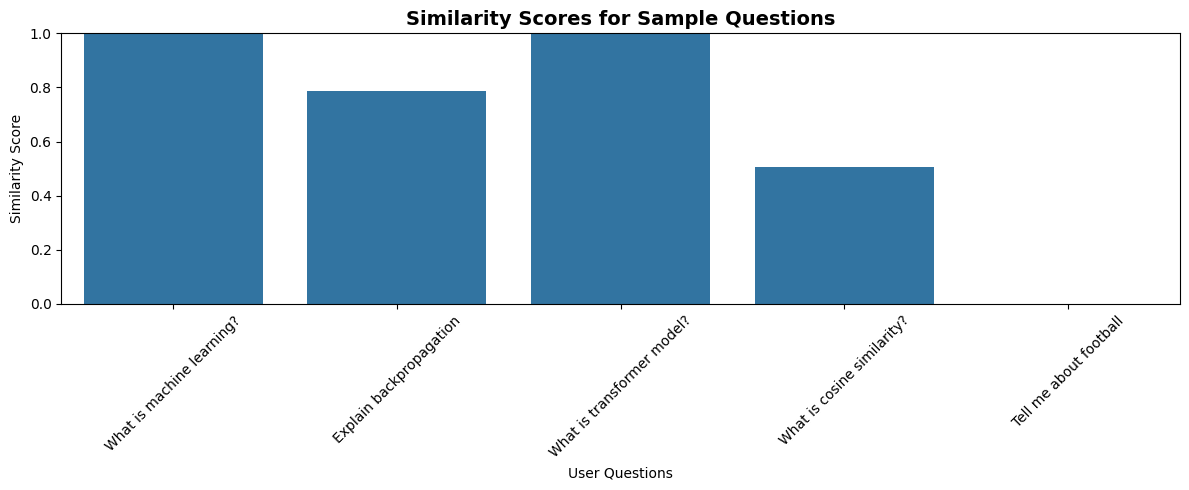

,question,similarity_score,matched_question
0,What is machine learning?,1.000,what is machine learning
1,Explain backpropagation,0.787,what is backpropagation
2,What is transformer model?,1.000,what is a transformer model
3,What is cosine similarity?,0.507,what is the significance of the cosine similar...
4,Tell me about football,0.000,None


In [31]:
# ============================================================
# CELL 10: Similarity Score Visualization
# ============================================================

def plot_similarity_scores(test_questions, df, tfidf_vectorizer, question_vectors):
    """
    Visualize best similarity scores for sample user questions.
    """

    # Store prediction results
    results = []

    # Loop through test questions
    for question in test_questions:

        # Get chatbot response
        response = chatbot_response(
            user_query=question,
            df=df,
            tfidf_vectorizer=tfidf_vectorizer,
            question_vectors=question_vectors,
            domain="education",
            threshold=0.30,
            top_k=3
        )

        # Store result
        results.append({
            "question": question,
            "similarity_score": response["similarity_score"],
            "matched_question": response["matched_question"]
        })

    # Convert results into dataframe
    results_df = pd.DataFrame(results)

    # Plot similarity scores
    plt.figure(figsize=(12, 5))
    sns.barplot(data=results_df, x="question", y="similarity_score")
    plt.title("Similarity Scores for Sample Questions", fontsize=14, fontweight="bold")
    plt.xlabel("User Questions")
    plt.ylabel("Similarity Score")
    plt.xticks(rotation=45)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.savefig("figures/similarity_scores.png", dpi=300, bbox_inches="tight")
    plt.show()

    return results_df


# Plot similarity scores
similarity_results_df = plot_similarity_scores(
    test_questions,
    df,
    tfidf_vectorizer,
    question_vectors
)

# Display results
similarity_results_df

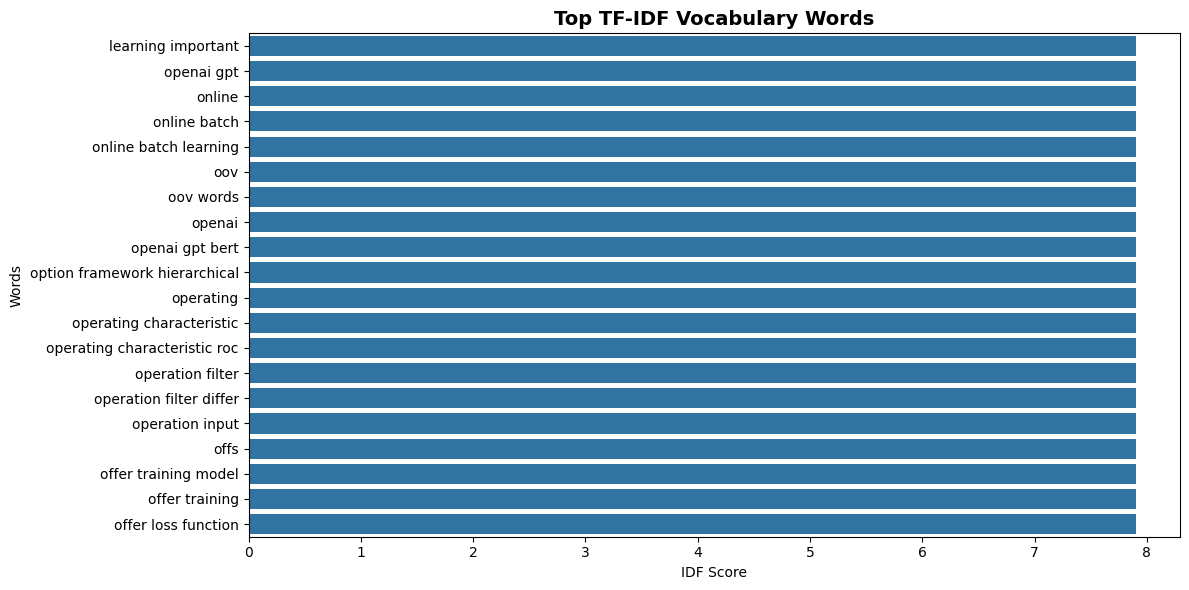

,word,idf_score
4965,learning important,7.900731
6232,openai gpt,7.900731
6226,online,7.900731
6227,online batch,7.900731
6228,online batch learning,7.900731
6229,oov,7.900731
6230,oov words,7.900731
6231,openai,7.900731
6233,openai gpt bert,7.900731
6283,option framework hierarchical,7.900731


In [32]:
# ============================================================
# CELL 11: Top Words from TF-IDF Vocabulary
# ============================================================

def plot_top_tfidf_words(tfidf_vectorizer, top_n=20):
    """
    Visualize top words from TF-IDF vocabulary.
    """

    # Get feature names from vectorizer
    feature_names = tfidf_vectorizer.get_feature_names_out()

    # Get IDF values
    idf_values = tfidf_vectorizer.idf_

    # Create dataframe
    tfidf_df = pd.DataFrame({
        "word": feature_names,
        "idf_score": idf_values
    })

    # Sort by IDF score
    tfidf_df = tfidf_df.sort_values(by="idf_score", ascending=False).head(top_n)

    # Plot top TF-IDF words
    plt.figure(figsize=(12, 6))
    sns.barplot(data=tfidf_df, x="idf_score", y="word")
    plt.title("Top TF-IDF Vocabulary Words", fontsize=14, fontweight="bold")
    plt.xlabel("IDF Score")
    plt.ylabel("Words")
    plt.tight_layout()
    plt.savefig("figures/top_tfidf_words.png", dpi=300, bbox_inches="tight")
    plt.show()

    return tfidf_df


# Plot top TF-IDF words
top_tfidf_words_df = plot_top_tfidf_words(
    tfidf_vectorizer,
    top_n=20
)

# Display dataframe
top_tfidf_words_df

In [33]:
# ============================================================
# CELL 12: Save Model, Vectorizer, and Dataset
# ============================================================

def save_project_files(df, tfidf_vectorizer, question_vectors):
    """
    Save cleaned dataset, TF-IDF vectorizer, and question vectors.
    """

    # Save cleaned dataset
    df.to_csv(os.path.join("models", "clean_qa_dataset.csv"), index=False)

    # Save TF-IDF vectorizer
    with open(os.path.join("models", "tfidf_vectorizer.pkl"), "wb") as file:
        pickle.dump(tfidf_vectorizer, file)

    # Save question vectors
    with open(os.path.join("models", "question_vectors.pkl"), "wb") as file:
        pickle.dump(question_vectors, file)

    # Print confirmation
    print("Project files saved successfully!")
    print("Saved Dataset:", os.path.join("models", "clean_qa_dataset.csv"))
    print("Saved Vectorizer:", os.path.join("models", "tfidf_vectorizer.pkl"))
    print("Saved Question Vectors:", os.path.join("models", "question_vectors.pkl"))


# Save project files
save_project_files(
    df,
    tfidf_vectorizer,
    question_vectors
)

Project files saved successfully!
Saved Dataset: models\clean_qa_dataset.csv
Saved Vectorizer: models\tfidf_vectorizer.pkl
Saved Question Vectors: models\question_vectors.pkl


In [36]:
# ============================================================
# CELL 13: Load Saved Model Files
# ============================================================

def load_project_files():
    """
    Load saved dataset, TF-IDF vectorizer, and question vectors.
    """

    # Load cleaned dataset
    loaded_df = pd.read_csv(os.path.join("models", "clean_qa_dataset.csv"))

    # Load TF-IDF vectorizer
    with open(os.path.join("models", "tfidf_vectorizer.pkl"), "rb") as file:
        loaded_vectorizer = pickle.load(file)

    # Load question vectors
    with open(os.path.join("models", "question_vectors.pkl"), "rb") as file:
        loaded_question_vectors = pickle.load(file)

    # Print confirmation
    print("Saved project files loaded successfully!")

    return loaded_df, loaded_vectorizer, loaded_question_vectors


# Load saved files
loaded_df, loaded_vectorizer, loaded_question_vectors = load_project_files()

Saved project files loaded successfully!


In [37]:
# ============================================================
# CELL 14: Test Loaded Model
# ============================================================

# Test query
query = "What is reinforcement learning?"

# Get response from loaded model
response = chatbot_response(
    user_query=query,
    df=loaded_df,
    tfidf_vectorizer=loaded_vectorizer,
    question_vectors=loaded_question_vectors,
    domain="education",
    threshold=0.30,
    top_k=3
)

# Print result
print("User Question:", query)
print("Matched Question:", response["matched_question"])
print("Similarity Score:", response["similarity_score"])
print("Bot Answer:", response["answer"])

User Question: What is reinforcement learning?
Matched Question: what is reinforcement learning
Similarity Score: 1.0
Bot Answer: Reinforcement learning involves an agent learning from interactions with an environment to maximize rewards.


In [38]:
# ============================================================
# CELL 15: Chatbot Style Testing Loop
# ============================================================

def qa_chatbot(df, tfidf_vectorizer, question_vectors):
    """
    Run the Q&A chatbot in terminal-style mode.
    """

    # Print starting message
    print("AI/Data Science Q&A Chatbot")
    print("Domain: education")
    print("Type 'exit' to stop.\n")

    # Start chatbot loop
    while True:

        # Take user input
        user_input = input("You: ")

        # Stop chatbot
        if user_input.lower() in ["exit", "quit", "bye"]:
            print("Bot: Goodbye!")
            break

        # Get chatbot response
        response = chatbot_response(
            user_query=user_input,
            df=df,
            tfidf_vectorizer=tfidf_vectorizer,
            question_vectors=question_vectors,
            domain="education",
            threshold=0.30,
            top_k=3
        )

        # Print chatbot response
        print("Matched Question:", response["matched_question"])
        print("Similarity Score:", response["similarity_score"])
        print("Bot:", response["answer"])

        # Print top matches
        print("\nTop Matches:")
        for match in response["top_matches"]:
            print("-", match["matched_question"], "| Score:", match["similarity_score"])

        print("-" * 50)


# Run chatbot
qa_chatbot(
    loaded_df,
    loaded_vectorizer,
    loaded_question_vectors
)

AI/Data Science Q&A Chatbot
Domain: education
Type 'exit' to stop.

Bot: Goodbye!


In [39]:
# ============================================================
# CELL 16: Final Project Summary
# ============================================================

def final_project_summary(df):
    """
    Print final project summary.
    """

    # Print completion message
    print("Domain-Specific Q&A Chatbot Completed Successfully!")

    # Print dataset information
    print("\nDataset Information:")
    print("Total Questions:", len(df))
    print("Domains:", df["domain"].unique().tolist())

    # Print saved files
    print("\nSaved Model Files:")
    print("Clean Dataset:", os.path.join("models", "clean_qa_dataset.csv"))
    print("TF-IDF Vectorizer:", os.path.join("models", "tfidf_vectorizer.pkl"))
    print("Question Vectors:", os.path.join("models", "question_vectors.pkl"))

    # Print saved figures
    print("\nSaved Figures:")
    print("Domain Distribution:", os.path.join("figures", "domain_distribution.png"))
    print("Question Length Distribution:", os.path.join("figures", "question_length_distribution.png"))
    print("Answer Length Distribution:", os.path.join("figures", "answer_length_distribution.png"))
    print("Similarity Scores:", os.path.join("figures", "similarity_scores.png"))
    print("Top TF-IDF Words:", os.path.join("figures", "top_tfidf_words.png"))

    # Print implemented features
    print("""
Implemented Features:
1. Dataset loading and exploration
2. Dataset cleaning
3. Missing value handling
4. Duplicate removal
5. Domain-based filtering
6. Text preprocessing
7. TF-IDF feature extraction
8. N-gram support
9. Cosine similarity matching
10. Similarity threshold
11. Unknown question handling
12. Top matched questions
13. Matched question display
14. Similarity score display
15. Dataset visualization
16. TF-IDF vocabulary visualization
17. Model saving using pickle
18. Saved model loading and testing
19. Chatbot-style testing loop
20. Modular reusable functions
""")


# Show final summary
final_project_summary(df)

Domain-Specific Q&A Chatbot Completed Successfully!

Dataset Information:
Total Questions: 1985
Domains: ['education']

Saved Model Files:
Clean Dataset: models\clean_qa_dataset.csv
TF-IDF Vectorizer: models\tfidf_vectorizer.pkl
Question Vectors: models\question_vectors.pkl

Saved Figures:
Domain Distribution: figures\domain_distribution.png
Question Length Distribution: figures\question_length_distribution.png
Answer Length Distribution: figures\answer_length_distribution.png
Similarity Scores: figures\similarity_scores.png
Top TF-IDF Words: figures\top_tfidf_words.png

Implemented Features:
1. Dataset loading and exploration
2. Dataset cleaning
3. Missing value handling
4. Duplicate removal
5. Domain-based filtering
6. Text preprocessing
7. TF-IDF feature extraction
8. N-gram support
9. Cosine similarity matching
10. Similarity threshold
11. Unknown question handling
12. Top matched questions
13. Matched question display
14. Similarity score display
15. Dataset visualization
16. TF-I